# Deep Learning for Tabular Data

Two models:
1. **MLP** — properly regularised baseline (BatchNorm, Dropout, AdamW, cosine LR, SMOTE)
2. **FT-Transformer** — Feature Tokenizer + Transformer via `pytorch-tabular`

All features arrive from `preprocessing/pipeline.py` (already scaled). Deep learning models receive the same preprocessed data as the boosting models for a fair comparison.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import torch
import warnings
warnings.filterwarnings('ignore')

from config import OUTPUTS_DIR, MODELS_DIR, RESULTS_CSV_PATH, RANDOM_SEED, PIPELINE_PATH
from models.deep_learning import (
    train_mlp,
    train_ft_transformer,
    plot_loss_curves,
    plot_final_comparison,
    evaluate_dl,
)
from preprocessing.pipeline import PreprocessingPipeline

print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.3.0+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Load Preprocessed Data

Load the numpy arrays saved during Phase 1 (already scaled by `PreprocessingPipeline`). Also reload the pipeline to get `feature_cols` for the FT-Transformer DataFrame.

In [2]:
X_train = np.load(os.path.join(OUTPUTS_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(OUTPUTS_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(OUTPUTS_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(OUTPUTS_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(OUTPUTS_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(OUTPUTS_DIR, 'y_test.npy'))

# Load pipeline to retrieve feature column names
pipeline = PreprocessingPipeline.load(PIPELINE_PATH)
feature_names = pipeline.feature_cols

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Features ({len(feature_names)}): {feature_names}')
print(f'\nTrain class distribution:')
unique, counts = np.unique(y_train, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Class {c}: {n:,} ({n/len(y_train):.1%})')

Train: (5159638, 20)  Val: (1119891, 20)  Test: (1120369, 20)
Features (20): ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Weather_Condition', 'Amenity', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Civil_Twilight', 'Duration_Seconds', 'Cluster']

Train class distribution:
  Class 1: 44,265 (0.9%)
  Class 2: 4,105,699 (79.6%)
  Class 3: 880,104 (17.1%)
  Class 4: 129,570 (2.5%)


## 2. MLP Baseline

Architecture: `input → 512 → BN → ReLU → Drop(0.3) → 256 → BN → ReLU → Drop(0.3) → 128 → BN → ReLU → Drop(0.2) → 4`

Training details:
- AdamW, lr=1e-3, weight_decay=1e-4
- CosineAnnealingLR
- CrossEntropyLoss with balanced class weights
- SMOTE on training data (same strategy as Boosting Models)
- Early stopping on val macro F1 (patience=15)

In [3]:
mlp_model, mlp_test_metrics, mlp_loss_history, mlp_val_f1s = train_mlp(
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    use_smote=False,   
    batch_size=2048,
    max_epochs=100,
    patience=15,
)

print('\nMLP Test Metrics:')
for k, v in mlp_test_metrics.items():
    print(f'  {k}: {v}')

MLP training on cuda
  Epoch   1/100  train_loss=1.0602  val_loss=0.9856  val_macro_F1=0.2789
  Epoch   5/100  train_loss=0.9281  val_loss=0.9727  val_macro_F1=0.3045
  Epoch  10/100  train_loss=0.9086  val_loss=1.5445  val_macro_F1=0.2417
  Epoch  15/100  train_loss=0.8941  val_loss=2.0121  val_macro_F1=0.1355
  Epoch  20/100  train_loss=0.8795  val_loss=2.0774  val_macro_F1=0.1803
  Early stopping at epoch 20 (best val macro F1=0.3045)

MLP test results: {'accuracy': 0.4173, 'macro_f1': 0.3043, 'weighted_f1': 0.507, 'f1_class_1': 0.1019, 'f1_class_2': 0.5315, 'f1_class_3': 0.4732, 'f1_class_4': 0.1108}
MLP saved to e:\Projects\Accident Severity Prediction\outputs\models\mlp_best.pt

MLP Test Metrics:
  accuracy: 0.4173
  macro_f1: 0.3043
  weighted_f1: 0.507
  f1_class_1: 0.1019
  f1_class_2: 0.5315
  f1_class_3: 0.4732
  f1_class_4: 0.1108


Saved: e:\Projects\Accident Severity Prediction\outputs\plots\mlp_loss_curves.png


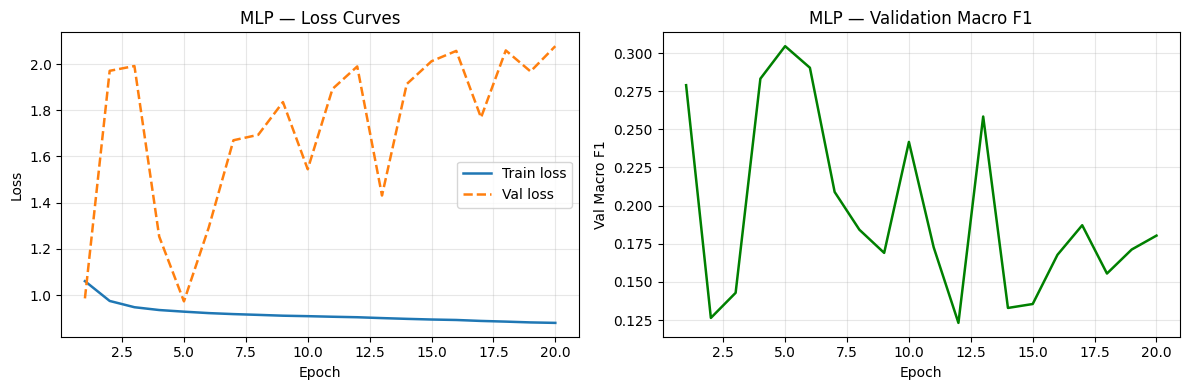

In [4]:
plot_loss_curves(
    mlp_loss_history,
    model_name='MLP',
    val_f1_history=mlp_val_f1s,
)

## 3. FT-Transformer

Feature Tokenizer + Transformer (Gorishniy et al., 2021) — native PyTorch implementation (no pytorch-tabular dependency).

Each feature is projected into a 32-dim embedding via a learned linear map (`FeatureTokenizer`). A learnable `[CLS]` token is prepended. Three pre-norm Transformer encoder layers with 8 attention heads let features attend to each other. The CLS output is classified by a linear head.

Config:
- `d_token=32`, `n_heads=8`, `n_blocks=3`
- Gradient clipping (max_norm=1.0), AdamW, CosineAnnealingLR, lr=1e-4
- `batch_size=1024`, `max_epochs=30`, early stopping on val macro F1 (patience=10)

In [5]:
ft_model, ft_test_metrics, ft_loss_history, ft_val_f1s = train_ft_transformer(
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    feature_names=feature_names,
    use_smote=False,   
    batch_size=1024,
    max_epochs=50,
    patience=10,
    lr=1e-3,           
)

print('\nFT-Transformer Test Metrics:')
for k, v in ft_test_metrics.items():
    print(f'  {k}: {v}')

FT-Transformer training on cuda
  Epoch   1/50  train_loss=0.9427  val_loss=0.8637  val_macro_F1=0.2976
  Epoch   5/50  train_loss=0.8519  val_loss=0.8732  val_macro_F1=0.3459
  Epoch  10/50  train_loss=0.8293  val_loss=0.7967  val_macro_F1=0.3477
  Epoch  15/50  train_loss=0.8142  val_loss=0.7931  val_macro_F1=0.3375
  Epoch  20/50  train_loss=0.8064  val_loss=0.8124  val_macro_F1=0.3245
  Epoch  25/50  train_loss=0.7947  val_loss=0.7727  val_macro_F1=0.3443
  Early stopping at epoch 28 (best val macro F1=0.3557)

FT-Transformer test results: {'accuracy': 0.5293, 'macro_f1': 0.3559, 'weighted_f1': 0.6089, 'f1_class_1': 0.1073, 'f1_class_2': 0.6525, 'f1_class_3': 0.497, 'f1_class_4': 0.1669}
FT-Transformer saved to e:\Projects\Accident Severity Prediction\outputs\models\ft_transformer_best.pt

FT-Transformer Test Metrics:
  accuracy: 0.5293
  macro_f1: 0.3559
  weighted_f1: 0.6089
  f1_class_1: 0.1073
  f1_class_2: 0.6525
  f1_class_3: 0.497
  f1_class_4: 0.1669


Saved: e:\Projects\Accident Severity Prediction\outputs\plots\ft-transformer_loss_curves.png


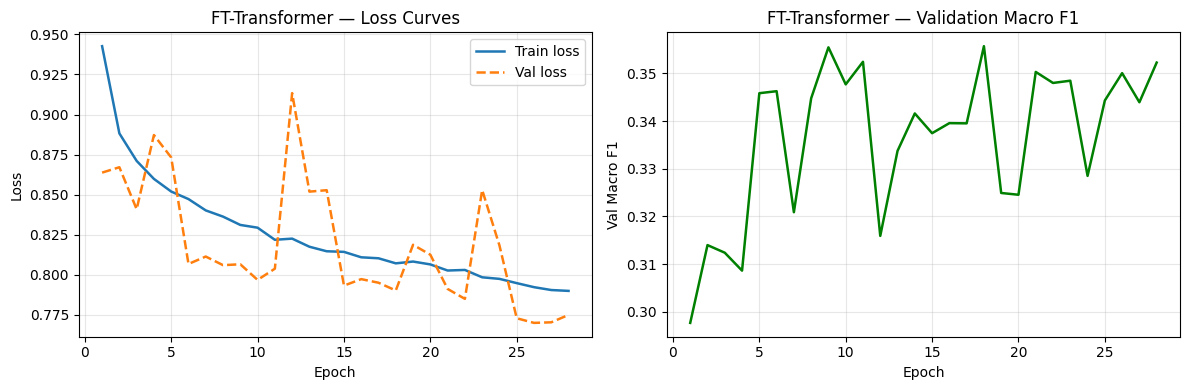

In [6]:
plot_loss_curves(
    ft_loss_history,
    model_name='FT-Transformer',
    val_f1_history=ft_val_f1s,
)

## 4. Final Comparison: All Models (Phases 2–4)

In [ ]:
# Load results saved by the boosting notebook
prev_results_df = pd.read_csv(RESULTS_CSV_PATH, index_col=0)

# Add MLP and FT results
phase4 = {
    'MLP (improved)':  mlp_test_metrics,
    'FT-Transformer':  ft_test_metrics,
}

phase4_df = pd.DataFrame(phase4).T
phase4_df.index.name = 'Model'

# Combine with previous results
combined_df = pd.concat([prev_results_df, phase4_df])

# Save updated results CSV
combined_df.to_csv(RESULTS_CSV_PATH)
print(f'Results saved to {RESULTS_CSV_PATH}')

# Display table
display_cols = ['accuracy', 'macro_f1', 'weighted_f1', 'f1_class_1', 'f1_class_2', 'f1_class_3', 'f1_class_4']
combined_df[display_cols].style \
    .format('{:.4f}') \
    .background_gradient(subset=['macro_f1'], cmap='RdYlGn') \
    .background_gradient(subset=['f1_class_1', 'f1_class_4'], cmap='RdYlGn')

Results saved to e:\Projects\Accident Severity Prediction\outputs\results\all_model_results.csv


,accuracy,macro_f1,weighted_f1,f1_class_1,f1_class_2,f1_class_3,f1_class_4
Model,,,,,,,
XGBoost_Optuna,0.7230,0.5021,0.7533,0.3146,0.8104,0.5741,0.3094
XGBoost_Optuna+Thresholds,0.7503,0.5062,0.7771,0.2976,0.8379,0.5874,0.3019
LightGBM_Optuna,0.7214,0.5018,0.7515,0.3254,0.8097,0.5673,0.3046
LightGBM_Optuna+Thresholds,0.7496,0.5070,0.7759,0.3115,0.8378,0.5813,0.2974
CatBoost_Optuna,0.7169,0.4908,0.7479,0.3018,0.8063,0.5660,0.2889
CatBoost_Optuna+Thresholds,0.7466,0.4954,0.7738,0.2822,0.8365,0.5787,0.2840
MLP (improved),0.4173,0.3043,0.5070,0.1019,0.5315,0.4732,0.1108
FT-Transformer,0.5293,0.3559,0.6089,0.1073,0.6525,0.4970,0.1669


Saved: e:\Projects\Accident Severity Prediction\outputs\plots\phase4_final_comparison.png


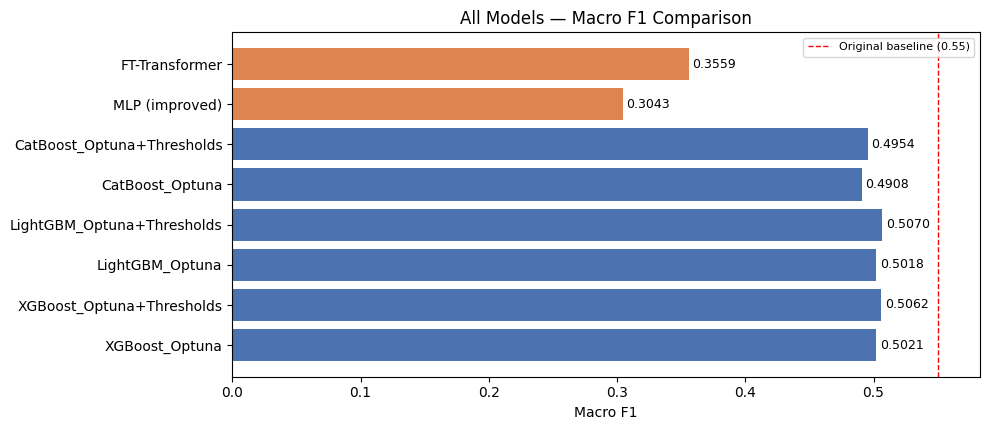

In [ ]:
# Build results dict for plot
plot_results = {}
for idx, row in combined_df.iterrows():
    plot_results[str(idx)] = row.to_dict()

plot_final_comparison(plot_results)

## 5. Side-by-Side Confusion Matrices: Best Boosting vs Best DL

Saved: e:\Projects\Accident Severity Prediction\outputs\plots\phase4_confusion_matrices.png


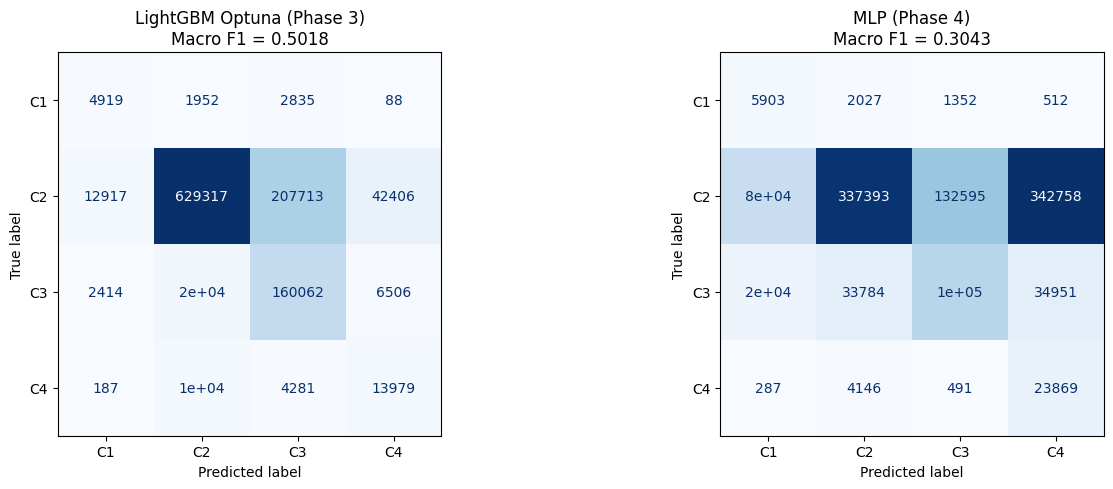

In [ ]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from config import LIGHTGBM_PATH, PLOTS_DIR
import torch
from models.deep_learning import _device

# Load best boosting model
lightgbm_model = joblib.load(LIGHTGBM_PATH)
lightgbm_preds = lightgbm_model.predict(X_test) + 1  # 0-indexed → 1-indexed

# MLP predictions (model is already in memory from cell above)
device = _device()
mlp_model.eval()
Xt = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    mlp_preds = mlp_model(Xt).argmax(dim=1).cpu().numpy() + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name in [
    (axes[0], lightgbm_preds, 'LightGBM Optuna (Phase 3)'),
    (axes[1], mlp_preds, 'MLP (Phase 4)'),
]:
    cm = confusion_matrix(y_test, preds, labels=[1, 2, 3, 4])
    disp = ConfusionMatrixDisplay(cm, display_labels=['C1', 'C2', 'C3', 'C4'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    macro = f1_score(y_test, preds, average='macro', zero_division=0)
    ax.set_title(f'{name}\nMacro F1 = {macro:.4f}')

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, 'phase4_confusion_matrices.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## 6. Summary

In [11]:
from sklearn.metrics import f1_score as _f1

print('=== Phase 4 Results Summary ===')
print(f'\nMLP (improved):')
print(f'  Accuracy:    {mlp_test_metrics["accuracy"]:.4f}')
print(f'  Macro F1:    {mlp_test_metrics["macro_f1"]:.4f}')
print(f'  F1 Class 1:  {mlp_test_metrics["f1_class_1"]:.4f}')
print(f'  F1 Class 4:  {mlp_test_metrics["f1_class_4"]:.4f}')

print(f'\nFT-Transformer:')
print(f'  Accuracy:    {ft_test_metrics["accuracy"]:.4f}')
print(f'  Macro F1:    {ft_test_metrics["macro_f1"]:.4f}')
print(f'  F1 Class 1:  {ft_test_metrics["f1_class_1"]:.4f}')
print(f'  F1 Class 4:  {ft_test_metrics["f1_class_4"]:.4f}')

best_dl = max(
    [(mlp_test_metrics["macro_f1"], 'MLP'),
     (ft_test_metrics["macro_f1"],  'FT-Transformer')]
)
print(f'\nBest DL model: {best_dl[1]} (macro F1 = {best_dl[0]:.4f})')
print(f'Phase 3 best: LightGBM (LightGBM_Optuna+Thresholds) (macro F1 = 0.5070)')

=== Phase 4 Results Summary ===

MLP (improved):
  Accuracy:    0.4173
  Macro F1:    0.3043
  F1 Class 1:  0.1019
  F1 Class 4:  0.1108

FT-Transformer:
  Accuracy:    0.5293
  Macro F1:    0.3559
  F1 Class 1:  0.1073
  F1 Class 4:  0.1669

Best DL model: FT-Transformer (macro F1 = 0.3559)
Phase 3 best: LightGBM (LightGBM_Optuna+Thresholds) (macro F1 = 0.5070)
